In [512]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib

In [513]:
df = pd.read_csv("D:\AI\Projects\Loan_Approval\data\loan_approval_dataset.csv")

<>:1: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:1: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\abhis\AppData\Local\Temp\ipykernel_2272\212860023.py:1: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  df = pd.read_csv("D:\AI\Projects\Loan_Approval\data\loan_approval_dataset.csv")


In [514]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [515]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [516]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [517]:
df.shape

(4269, 13)

In [518]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [519]:
df.duplicated().sum()

np.int64(0)

In [520]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

### Categorical Columns

In [521]:
df.select_dtypes(include='object').columns

Index([' education', ' self_employed', ' loan_status'], dtype='object')

### Numerical Columns

In [522]:
df.select_dtypes(include='number').columns

Index(['loan_id', ' no_of_dependents', ' income_annum', ' loan_amount',
       ' loan_term', ' cibil_score', ' residential_assets_value',
       ' commercial_assets_value', ' luxury_assets_value',
       ' bank_asset_value'],
      dtype='object')

In [523]:
df.columns = df.columns.str.strip()

In [524]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [525]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

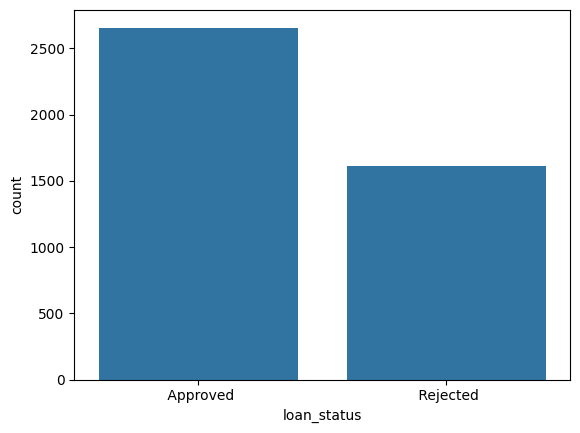

In [526]:
sns.countplot(x=df['loan_status'],data=df)
plt.show()

In [527]:
df.drop('loan_id',axis=1,inplace=True)

In [528]:
df.select_dtypes(include='object').columns

Index(['education', 'self_employed', 'loan_status'], dtype='object')

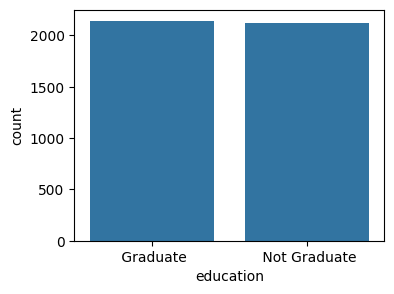

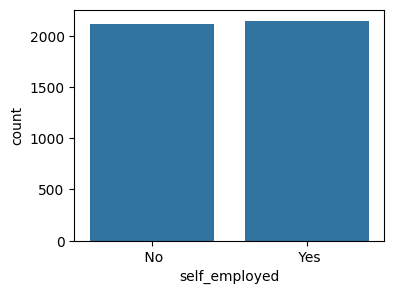

In [529]:
cat_cols = ['education', 'self_employed']

for col in cat_cols:
    plt.figure(figsize=(4,3))
    sns.countplot(x=col,data=df)
    plt.show()


In [530]:
df.select_dtypes(include='number').columns

Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

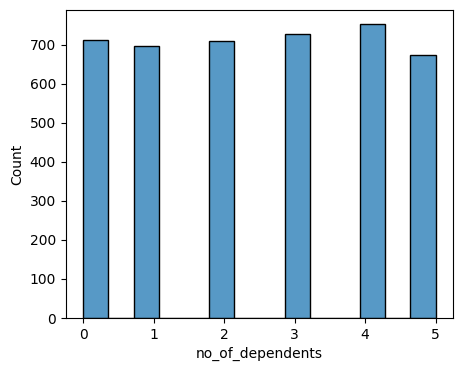

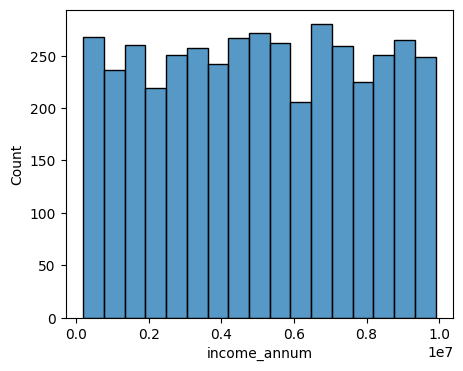

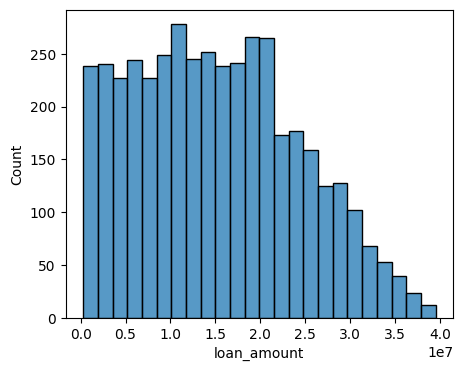

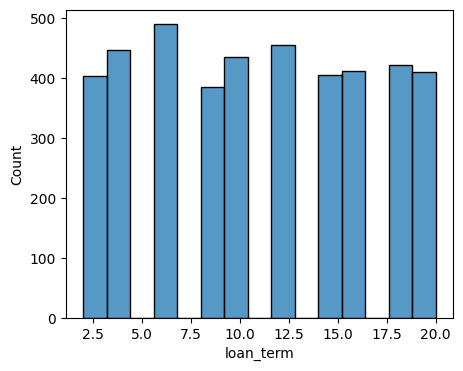

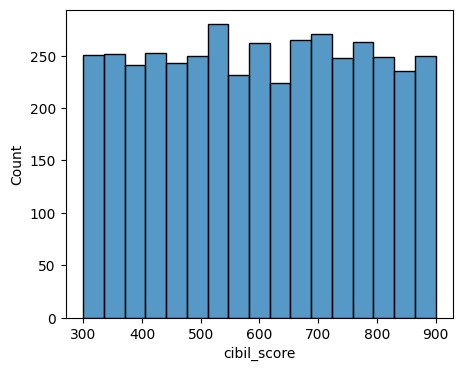

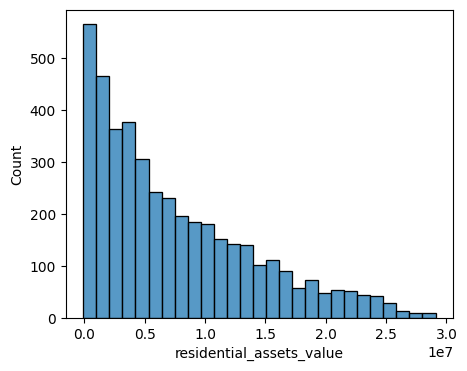

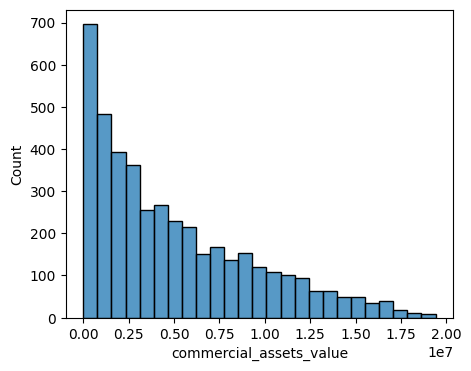

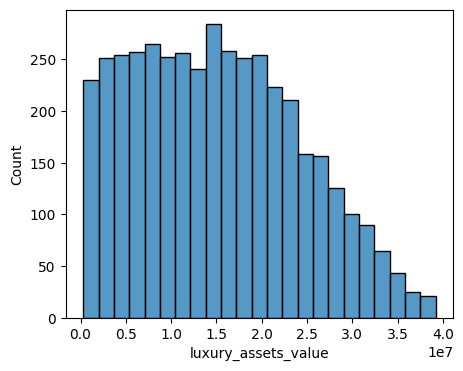

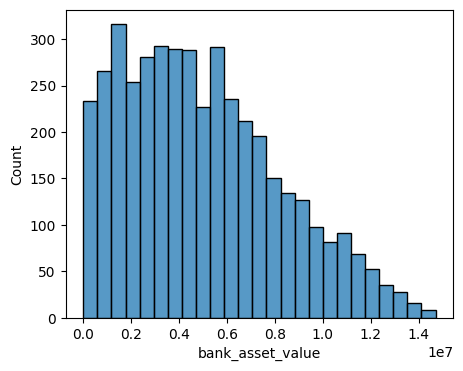

In [531]:
num_cols = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value']

for num in num_cols:
    plt.figure(figsize=(5,4))
    sns.histplot(x=num,data=df)

### Detecting Outlier

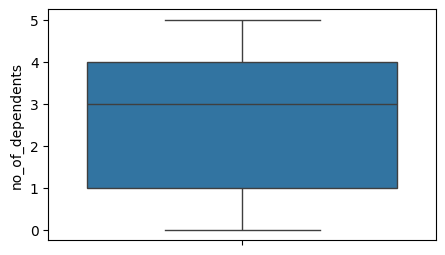

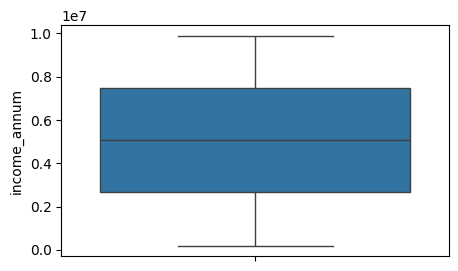

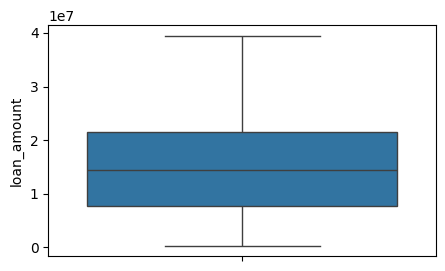

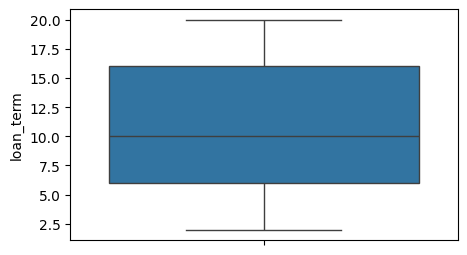

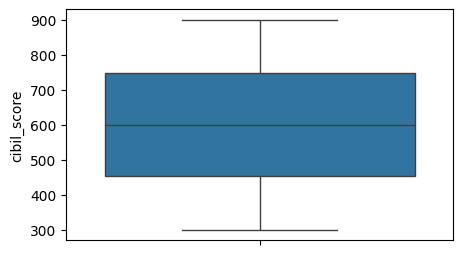

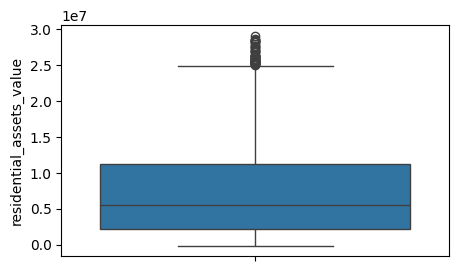

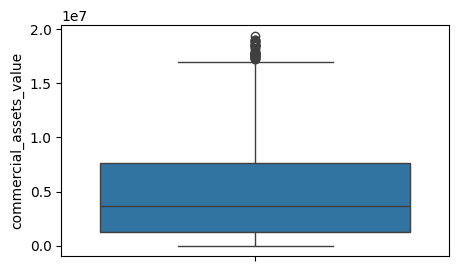

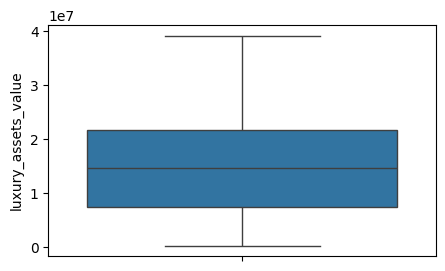

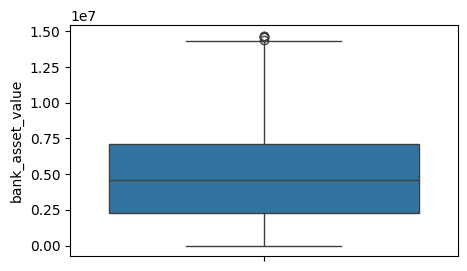

In [532]:
num_cols = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value']

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(y=col,data=df)

<Axes: >

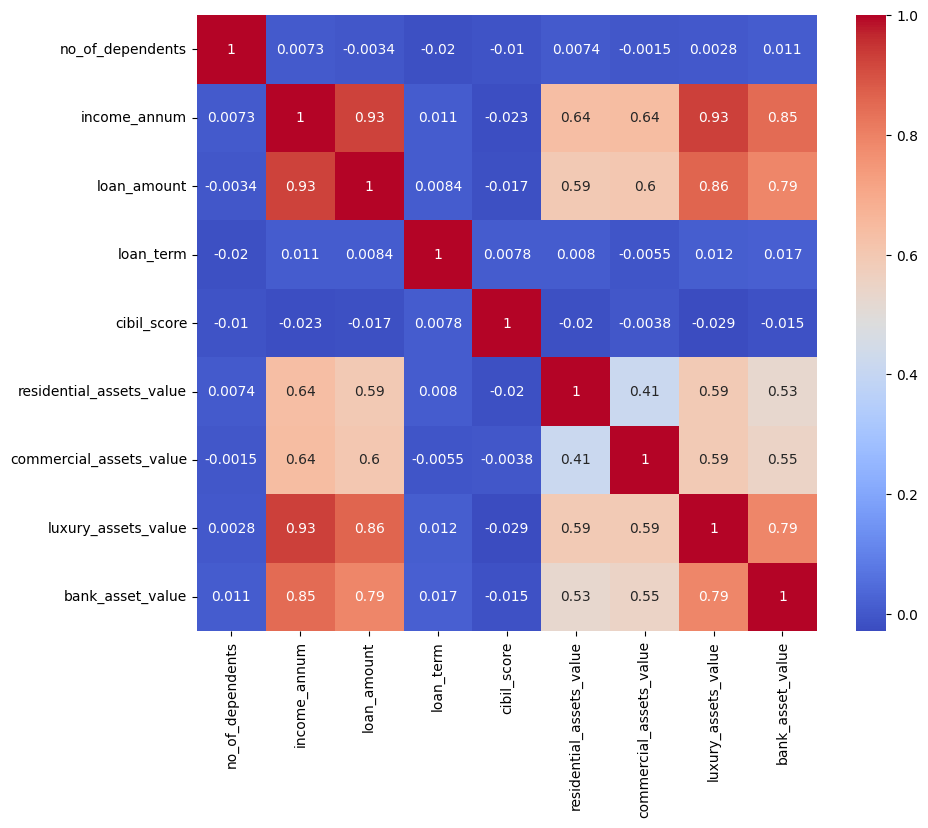

In [533]:
plt.figure(figsize=(10,8))
corr = df[num_cols].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')

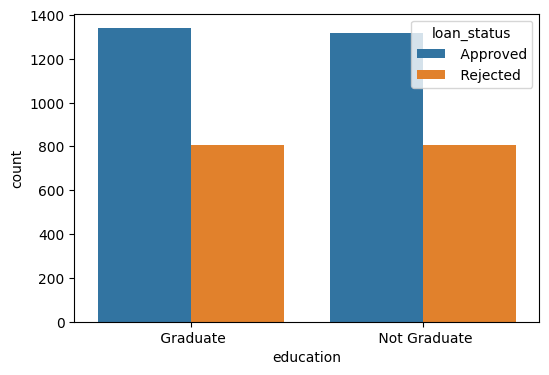

In [534]:
plt.figure(figsize=(6,4))
sns.countplot(x='education',hue='loan_status',data=df)
plt.show()

### Loan status vs Self Employed


<Axes: xlabel='self_employed', ylabel='count'>

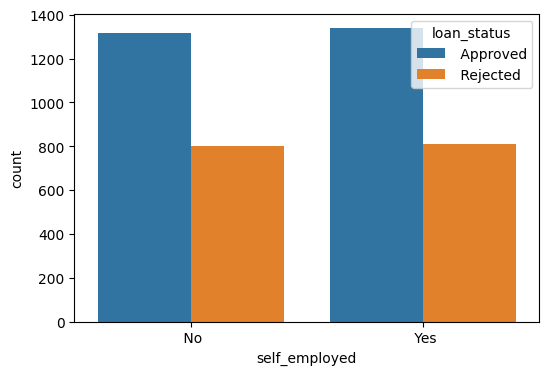

In [535]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['self_employed'],hue='loan_status',data=df)

<Axes: xlabel='self_employed', ylabel='count'>

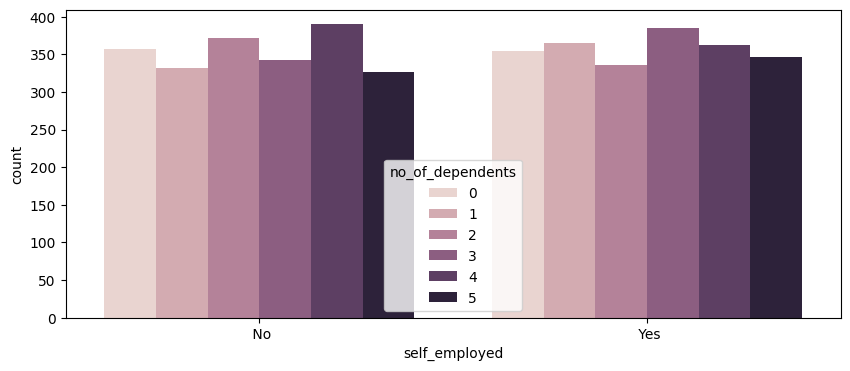

In [536]:
plt.figure(figsize=(10,4))
sns.countplot(x='self_employed',hue='no_of_dependents',data=df)

In [537]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

### CIBIL_Score Distribution

<Axes: xlabel='cibil_score', ylabel='Count'>

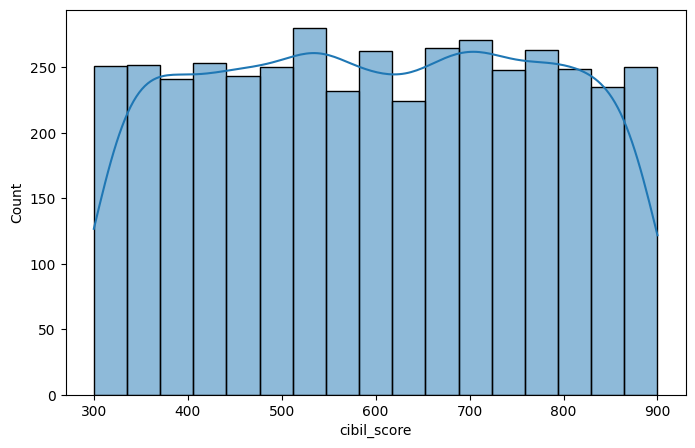

In [538]:
plt.figure(figsize=(8,5))
sns.histplot(df['cibil_score'],kde=True)

### Cibil score vs Loan status

<Axes: xlabel='loan_status', ylabel='cibil_score'>

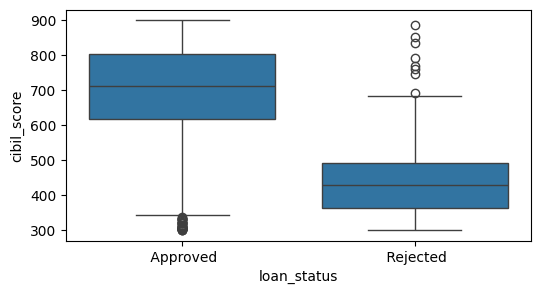

In [539]:
plt.figure(figsize=(6,3))
sns.boxplot(x='loan_status',y='cibil_score',data=df)

### Income Distribution

<Axes: xlabel='income_annum', ylabel='Count'>

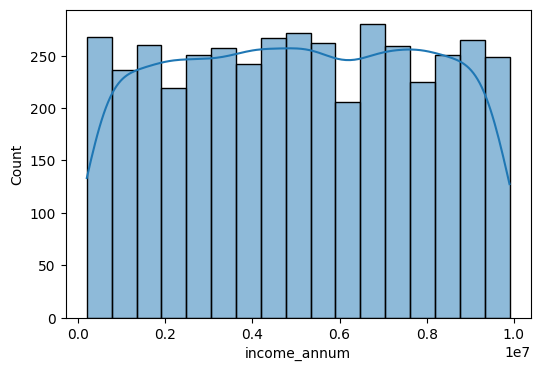

In [540]:
plt.figure(figsize=(6,4))
sns.histplot(df['income_annum'],kde=True)

### Loan Amount Distribution

<Axes: xlabel='loan_amount', ylabel='Count'>

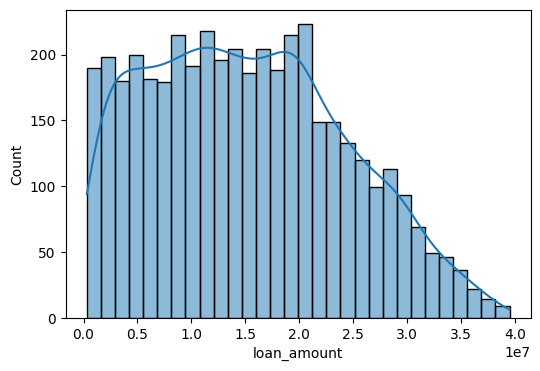

In [541]:
plt.figure(figsize=(6,4))
sns.histplot(df['loan_amount'],bins=30,kde=True)

### Loan Amount vs Income

<Axes: xlabel='loan_amount', ylabel='income_annum'>

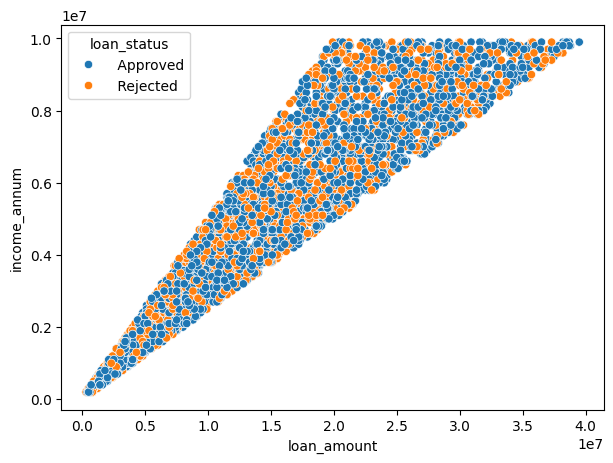

In [542]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='loan_amount',y='income_annum',hue='loan_status',data=df)

###  Cibil Score vs Loan Amount

<Axes: xlabel='cibil_score', ylabel='loan_amount'>

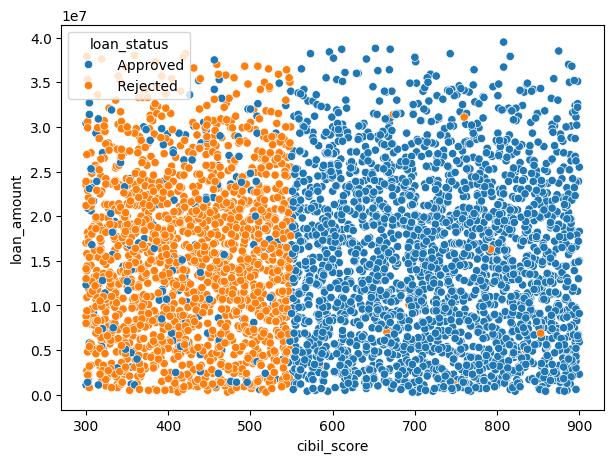

In [543]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='cibil_score',y='loan_amount',hue='loan_status',data=df)

#### Asset Comparsion

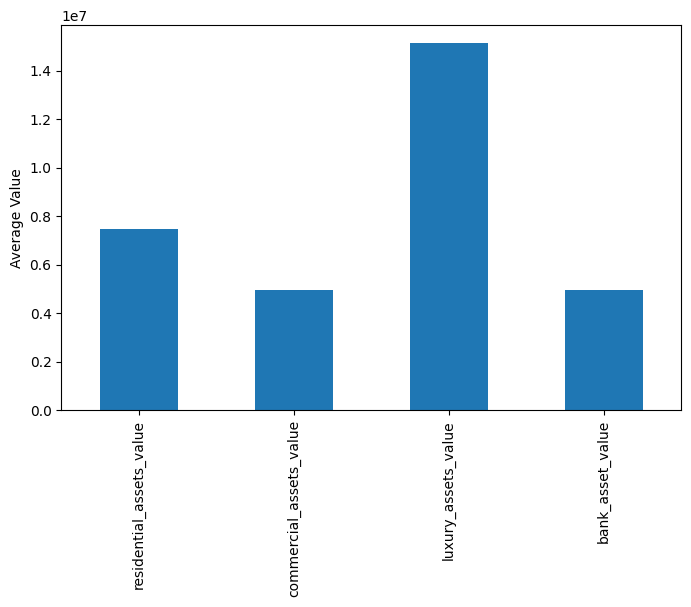

In [544]:
assets = [
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

df[assets].mean().plot(kind='bar', figsize=(8,5))

plt.ylabel("Average Value")

plt.show()

### Asset Correlation

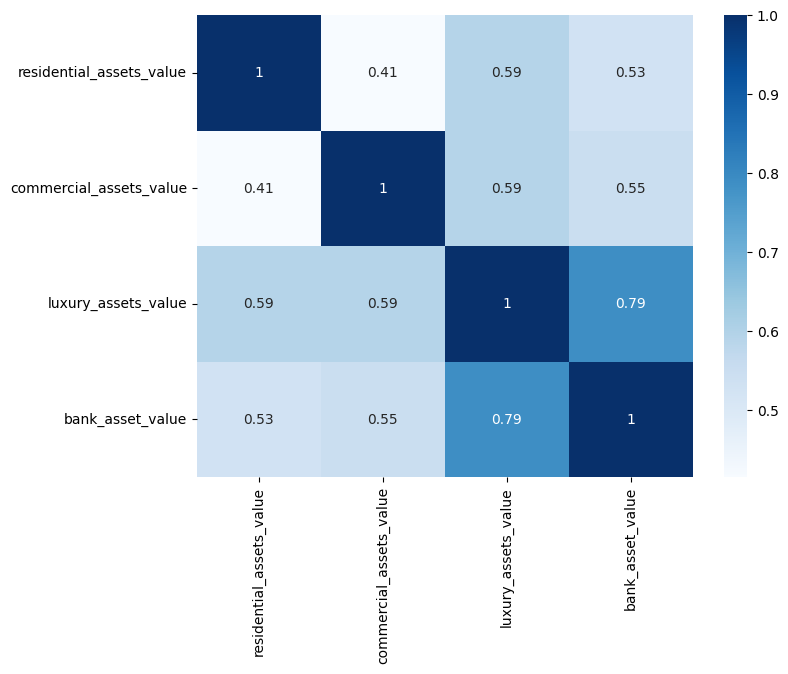

In [545]:
plt.figure(figsize=(8,6))

sns.heatmap(df[assets].corr(),annot=True,cmap='Blues')

plt.show()

In [546]:
df.select_dtypes(include='number').columns

Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

#### Preparing the dataset & Feature Engineering

In [547]:
df_model = df.copy()

In [548]:
df_model

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


### Encoding the target

In [549]:
df_model['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

### Encoding Numerical Columns

In [550]:
df_model["loan_status"] = df_model["loan_status"].str.strip().map({
 "Approved": 1,
 "Rejected":0
})

In [551]:
df_model['loan_status'].value_counts()

loan_status
1    2656
0    1613
Name: count, dtype: int64

In [552]:
df_model.select_dtypes(include='object').columns

Index(['education', 'self_employed'], dtype='object')

### Encoding Categorical Columns

In [553]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_col = ['education', 'self_employed']
for col in categorical_col:
    df_model[col]=le.fit_transform(df_model[col])

### Creating New Features

In [554]:
df_model["total_assets"] = (
    df_model['commercial_assets_value']+
    df_model['luxury_assets_value']+
    df_model['residential_assets_value']+
    df_model['bank_asset_value']
)

### Loan To Income ratio

In [555]:
df_model['loan_income_ration'] = (
  df_model["loan_amount"] / df_model["income_annum"]

)

### Asset Coverage Ratio

In [556]:
df_model["asset_coverage_ratio"] = (
    df_model["total_assets"] / df_model["loan_amount"]
)

In [557]:
X = df_model.drop('loan_status',axis=1)
y = df_model['loan_status']

In [558]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [559]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2860, 14)
(1409, 14)
(2860,)
(1409,)


### Featuring Scaling

In [560]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [561]:
print("Original Training Shape",X_train.shape)
print("Scaled Training Shape",X_train_scaled.shape)

Original Training Shape (2860, 14)
Scaled Training Shape (2860, 14)


In [562]:
joblib.dump(scaler , "../models/scaler.pkl")

['../models/scaler.pkl']

In [563]:
df_model.head()
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4269 non-null   int64  
 1   education                 4269 non-null   int64  
 2   self_employed             4269 non-null   int64  
 3   income_annum              4269 non-null   int64  
 4   loan_amount               4269 non-null   int64  
 5   loan_term                 4269 non-null   int64  
 6   cibil_score               4269 non-null   int64  
 7   residential_assets_value  4269 non-null   int64  
 8   commercial_assets_value   4269 non-null   int64  
 9   luxury_assets_value       4269 non-null   int64  
 10  bank_asset_value          4269 non-null   int64  
 11  loan_status               4269 non-null   int64  
 12  total_assets              4269 non-null   int64  
 13  loan_income_ration        4269 non-null   float64
 14  asset_co

### Train & Compare Models


In [564]:
def evaluate_model(model,X_train,y_train,X_test,y_test):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    print("="*60)
    print(type(model).__name__)
    print("="*60)

    print("Accuracy:",round(accuracy,3))
    print("Precision:",round(precision,3))
    print("Recall:",round(recall,3))
    print("F1:",round(f1,3))
    
    print("classification_report:")
    print(classification_report(y_test,y_pred))

    print("Confusion_matrix:",confusion_matrix(y_test,y_pred))

    return{
        "Model":type(model).__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

### Logistic Rgression

In [565]:
log_model = LogisticRegression(random_state=42)
log_result = evaluate_model(log_model, X_train_scaled,y_train , X_test_scaled,y_test)

LogisticRegression
Accuracy: 0.894
Precision: 0.911
Recall: 0.922
F1: 0.917
classification_report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       522
           1       0.91      0.92      0.92       887

    accuracy                           0.89      1409
   macro avg       0.89      0.88      0.89      1409
weighted avg       0.89      0.89      0.89      1409

Confusion_matrix: [[442  80]
 [ 69 818]]


### Decision Tree

In [566]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_result = evaluate_model(dt_model,X_train,y_train ,X_test,y_test)

DecisionTreeClassifier
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       522
           1       1.00      1.00      1.00       887

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

Confusion_matrix: [[522   0]
 [  0 887]]


### Random Forest

In [567]:
rf_model = RandomForestClassifier()
rf_result = evaluate_model(rf_model,X_train,y_train,X_test,y_test)

RandomForestClassifier
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       522
           1       1.00      1.00      1.00       887

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

Confusion_matrix: [[522   0]
 [  0 887]]


### XGBoost

In [568]:
xgb_model = XGBClassifier()
xgb_result = evaluate_model(xgb_model,X_train,y_train,X_test,y_test)

XGBClassifier
Accuracy: 0.999
Precision: 1.0
Recall: 0.999
F1: 0.999
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       522
           1       1.00      1.00      1.00       887

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

Confusion_matrix: [[522   0]
 [  1 886]]


In [569]:
print(results.columns)

Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1'], dtype='object')


In [570]:
results = pd.DataFrame([
    log_result,dt_result,rf_result,xgb_result
])
results.sort_values(by="Accuracy",ascending=True)

,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression,0.894251,0.910913,0.922210,0.916527
3,XGBClassifier,0.999290,1.000000,0.998873,0.999436
1,DecisionTreeClassifier,1.000000,1.000000,1.000000,1.000000
2,RandomForestClassifier,1.000000,1.000000,1.000000,1.000000


In [571]:
corr = df_model.corr(numeric_only=True)

corr["loan_status"].sort_values(ascending=False)

loan_status                 1.000000
cibil_score                 0.770518
loan_income_ration          0.087726
loan_amount                 0.016150
commercial_assets_value     0.008246
self_employed               0.000345
education                  -0.004918
bank_asset_value           -0.006778
total_assets               -0.011281
residential_assets_value   -0.014367
income_annum               -0.015189
luxury_assets_value        -0.015465
no_of_dependents           -0.018114
asset_coverage_ratio       -0.050070
loan_term                  -0.113036
Name: loan_status, dtype: float64

<Axes: >

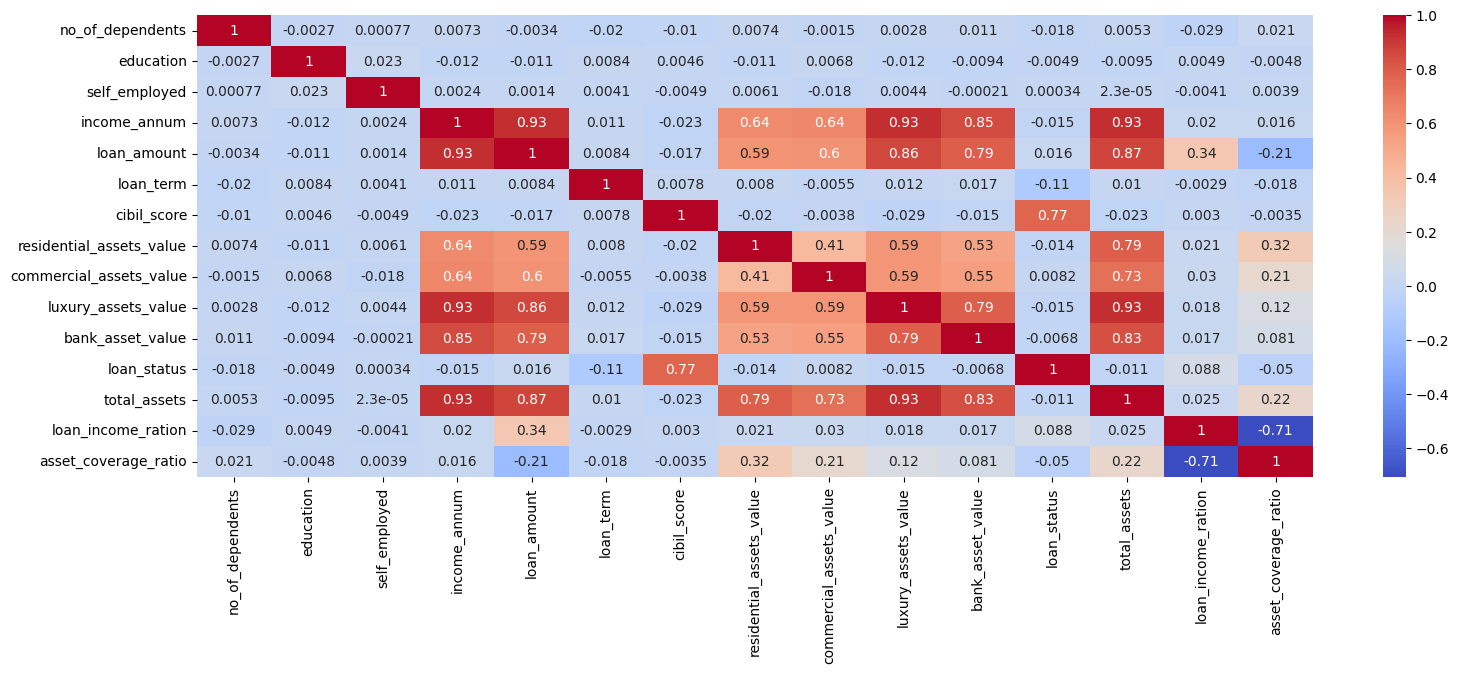

In [572]:

plt.figure(figsize=(18,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

In [573]:
print(y_train.value_counts())
print(y_test.value_counts())

loan_status
1    1769
0    1091
Name: count, dtype: int64
loan_status
1    887
0    522
Name: count, dtype: int64


In [574]:
print(X_train.index.intersection(X_test.index))

Index([], dtype='int64')


### Showing the Importance of feature to models

In [575]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

print(importance.sort_values(by="Importance", ascending=False))

                     Feature  Importance
6                cibil_score    0.782900
5                  loan_term    0.068323
12        loan_income_ration    0.034798
13      asset_coverage_ratio    0.025629
4                loan_amount    0.012674
9        luxury_assets_value    0.012627
11              total_assets    0.012124
7   residential_assets_value    0.011911
3               income_annum    0.011000
8    commercial_assets_value    0.010111
10          bank_asset_value    0.009792
0           no_of_dependents    0.005066
1                  education    0.001641
2              self_employed    0.001404


In [576]:
print(results)

                    Model  Accuracy  Precision    Recall        F1
0      LogisticRegression  0.894251   0.910913  0.922210  0.916527
1  DecisionTreeClassifier  1.000000   1.000000  1.000000  1.000000
2  RandomForestClassifier  1.000000   1.000000  1.000000  1.000000
3           XGBClassifier  0.999290   1.000000  0.998873  0.999436


In [577]:
print(df_model.shape)

(4269, 15)


In [578]:
print(df_model.duplicated().sum())

0


In [579]:
for col in X_train.columns:
    print(col, (X_train[col] == y_train).sum())

no_of_dependents 481
education 1426
self_employed 1440
income_annum 0
loan_amount 0
loan_term 0
cibil_score 0
residential_assets_value 13
commercial_assets_value 29
luxury_assets_value 0
bank_asset_value 3
total_assets 0
loan_income_ration 0
asset_coverage_ratio 5


In [580]:
from sklearn.metrics import accuracy_score

train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy : 1.0


In [581]:
print(X_train.columns.tolist())


['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'total_assets', 'loan_income_ration', 'asset_coverage_ratio']


In [582]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print("Average:", scores.mean())

[0.99882904 0.99882904 1.         1.         1.        ]
Average: 0.9995316159250585


In [584]:
import joblib

joblib.dump(rf_model, "../models/loan_approval_model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


In [585]:
model = joblib.load("../models/loan_approval_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

In [586]:
import numpy as np

def predict_loan(features):
    features = np.array(features).reshape(1, -1)

    features = scaler.transform(features)

    prediction = rf_model.predict(features)[0]

    if prediction == 1:
        return "Loan Approved ✅"
    else:
        return "Loan Rejected ❌"